<a href="https://colab.research.google.com/github/melissa-04/melisayla-biyoinformatik/blob/main/notebooks/spatial/02_uzamsal_kumeleme.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Uzamsal kümeleme

İkinci serinin hattını uzamsal veriye uyguluyoruz: normalizasyon, değişken genler, PCA, komşuluk grafiği, Leiden. Fonksiyonlar aynı; yeni olan, sonucu iki ayrı uzayda birden görmek — UMAP üzerinde ve dokunun kendi üzerinde. Bu defterin asıl sorusu şu: ifade benzerliğine göre kurulan kümeler, doku üzerinde de bir arada duruyor mu?

In [ ]:
%pip install -q scanpy leidenalg igraph

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 82.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 72.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 114.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.8/188.8 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.0/40.0 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 123.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.7/363.7 kB 26.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 124.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 5.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the sourc

## 1. Veriyi okumak

Veri 3.1'de yayımladığımız Zenodo kaydından geliyor (10.5281/zenodo.22758390). Dosya 182 MB olduğu için indirme birkaç dakika sürebilir.

In [ ]:
import warnings; warnings.filterwarnings('ignore')
import urllib.request
import scanpy as sc
import numpy as np

urllib.request.urlretrieve('https://zenodo.org/records/22758390/files/spatial_ders.h5ad?download=1', 'spatial_ders.h5ad')
v = sc.read_h5ad('spatial_ders.h5ad')
print('spot × gen:', v.shape)

spot × gen: (2702, 19653)


## 2. Tanıdık hat

2.2 ve 2.3'ün adımları, aynı gerekçelerle: ham sayımı katmana kopyala, CP10K'ya ölçekle, log1p al, değişken genleri bayrakla, `raw`'a tam matrisi sakla, bayraklılara daralt, ölçekle, PCA.

Bir noktaya dikkat edin: buradaki normalizasyon spot başına toplamı eşitler. Spotlar farklı sayıda hücre içerdiği için bu işlem, hücre sayısı farkını da ifade farkının içine katar — CP10K bu iki kaynağı ayıramaz. Uzamsal veride bu bilinen bir sınırdır ve yorumlar bu sınır hatırlanarak kurulur.

In [ ]:
v.layers['sayim'] = v.X.copy()
sc.pp.normalize_total(v, target_sum=1e4)
sc.pp.log1p(v)
sc.pp.highly_variable_genes(v, flavor='seurat', min_mean=0.0125, max_mean=3, min_disp=0.5)
print('değişken gen:', int(v.var.highly_variable.sum()))

v.raw = v
v = v[:, v.var.highly_variable].copy()
sc.pp.scale(v, max_value=10)
sc.tl.pca(v, svd_solver='arpack', n_comps=50)

vr = v.uns['pca']['variance_ratio'] * 100
print('İlk 5 bileşen (%):', np.round(vr[:5], 2))
print('İlk 10 kümülatif: %%%.1f' % vr[:10].sum())

değişken gen: 2614
İlk 5 bileşen (%): [8.51 3.67 3.36 2.43 1.68]
İlk 10 kümülatif: %24.3


## 3. Kümeleme

Komşuluk grafiği ve Leiden, 2.3-2.4'teki parametrelerle. İki çözünürlük deniyoruz; hangisinin okunur olduğuna doku üzerindeki görüntüye bakarak karar vereceğiz — uzamsal veride ek bir ölçüt var: kümeler doku üzerinde tutarlı bölgeler oluşturuyor mu, yoksa dağılmış mı?

In [ ]:
sc.pp.neighbors(v, n_neighbors=15, n_pcs=10)
sc.tl.leiden(v, resolution=0.5, key_added='leiden_05')
sc.tl.leiden(v, resolution=1.0, key_added='leiden_1')

print('resolution=0.5:', v.obs.leiden_05.nunique(), 'küme')
print('resolution=1.0:', v.obs.leiden_1.nunique(), 'küme')
print(v.obs.leiden_05.value_counts().sort_index())

resolution=0.5: 14 küme
resolution=1.0: 21 küme
leiden_05
0     377
1     316
2     287
3     282
4     256
5     255
6     254
7     185
8     175
9     103
10     84
11     58
12     49
13     21
Name: count, dtype: int64


## 4. İki uzay, tek sonuç

Aynı kümeleri iki ayrı yerde çiziyoruz. `sc.pl.umap` ifade uzayındaki yerleşimi, `sc.pl.spatial` dokunun üzerindeki gerçek konumu gösterir. Karşılaştırma bu serinin merkezindeki gözlemi verir: kümeleme algoritması koordinatları hiç görmedi — yalnız gen ifadesine baktı. Kümeler doku üzerinde yine de derli toplu bölgeler oluşturuyorsa, bu dokunun mimarisinin ifadeye yazılı olduğu anlamına gelir.

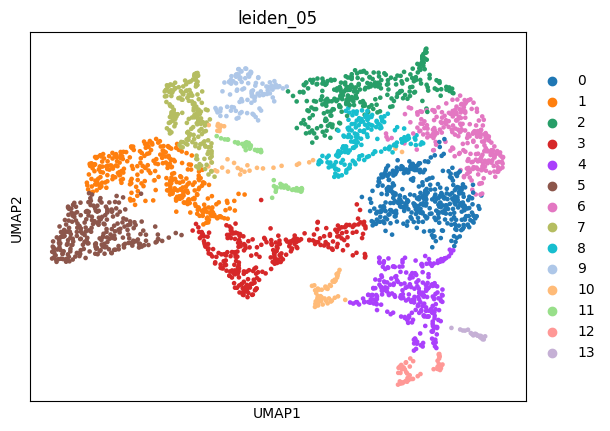

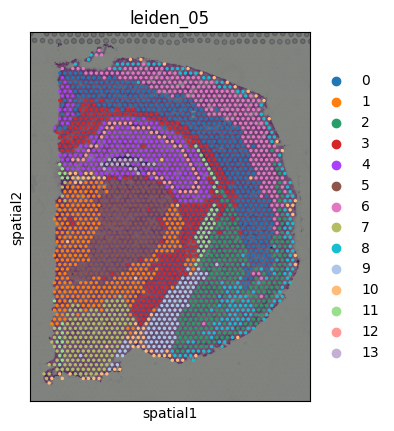

In [ ]:
sc.tl.umap(v)
sc.pl.umap(v, color='leiden_05')
sc.pl.spatial(v, color='leiden_05')

## 5. Anatomik işaretçiler

Küme numaralarını bölge adlarına bağlamak için bilinen beyin işaretçilerini doku üzerinde çiziyoruz:

- **Snap25** — nöronal sinaps proteini; nöron yoğun gri madde
- **Mbp, Plp1** — miyelin proteinleri; ak madde (oligodendrositler)
- **Hpca** — hipokampus zenginleştirilmiş
- **Ttr** — koroid pleksus işaretçisi

Bu genler `v.raw` içinde duruyor, yani daraltmadan etkilenmediler; `sc.pl.spatial` varsayılan olarak oradan okur.

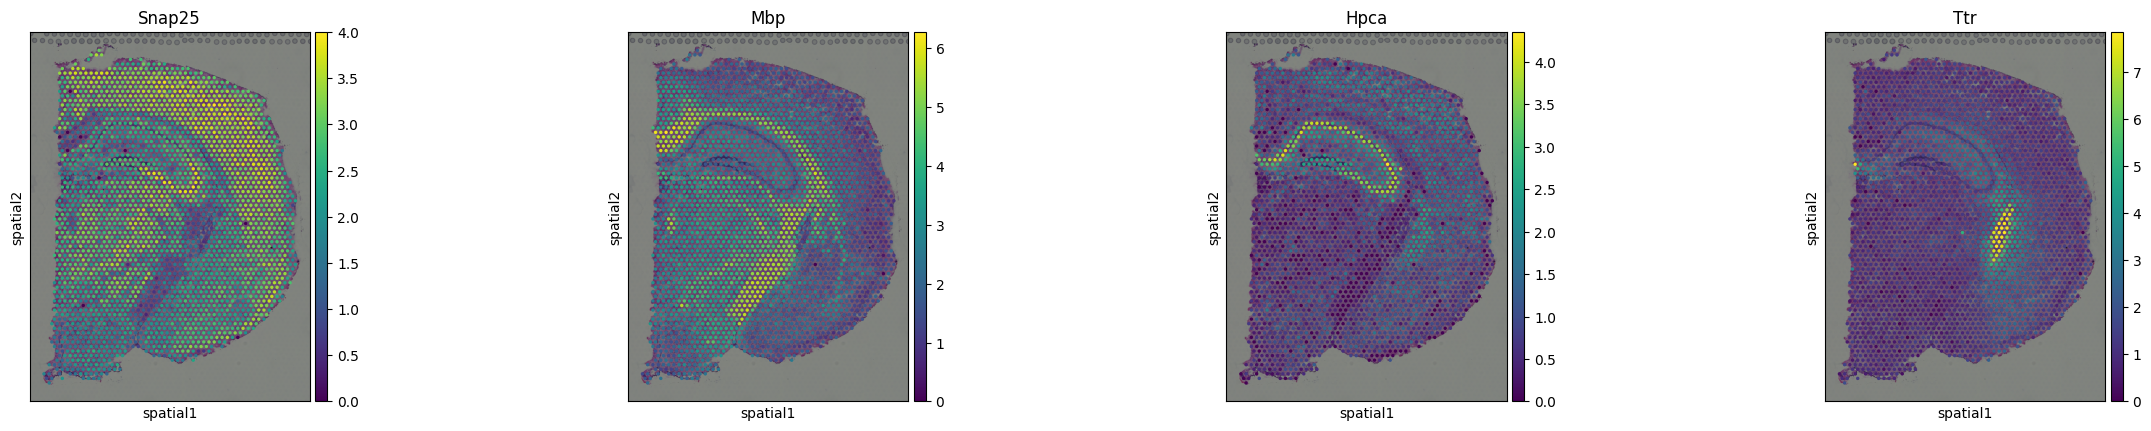

In [ ]:
sc.pl.spatial(v, color=['Snap25', 'Mbp', 'Hpca', 'Ttr'])

## Kendin dene

Üç görev. Birincisi: değişken gen sayınızı, ilk 5 bileşenin varyans yüzdelerini ve iki çözünürlükteki küme sayılarını not edin; PCA yüzdelerini 2.3'teki PBMC değerleriyle karşılaştırıp tek cümleyle yorumlayın. İkincisi, bu defterin ana sorusu: kümeler doku üzerinde dağınık mı, yoksa tutarlı bölgeler mi oluşturuyor — ve kümeleme koordinatları hiç görmediğine göre bu ne anlama geliyor? Üçüncüsü: dört işaretçi haritasına bakıp en az iki kümeyi anatomik bir bölgeyle eşleştirin (örneğin ak madde, hipokampus); hangi işaretçiye dayandığınızı yazın. Koştuğunuz defteri gönderin; yazı sizin sayılarınızla yazılacak.